In [2]:
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud

print("All dependencies successfully imported.")

All dependencies successfully imported.


In [3]:
def clean_text(text):
    """Clean raw text string formatting."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)       # Remove HTML tags
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove Emojis/non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()   # Clean up extra whitespace
    return text

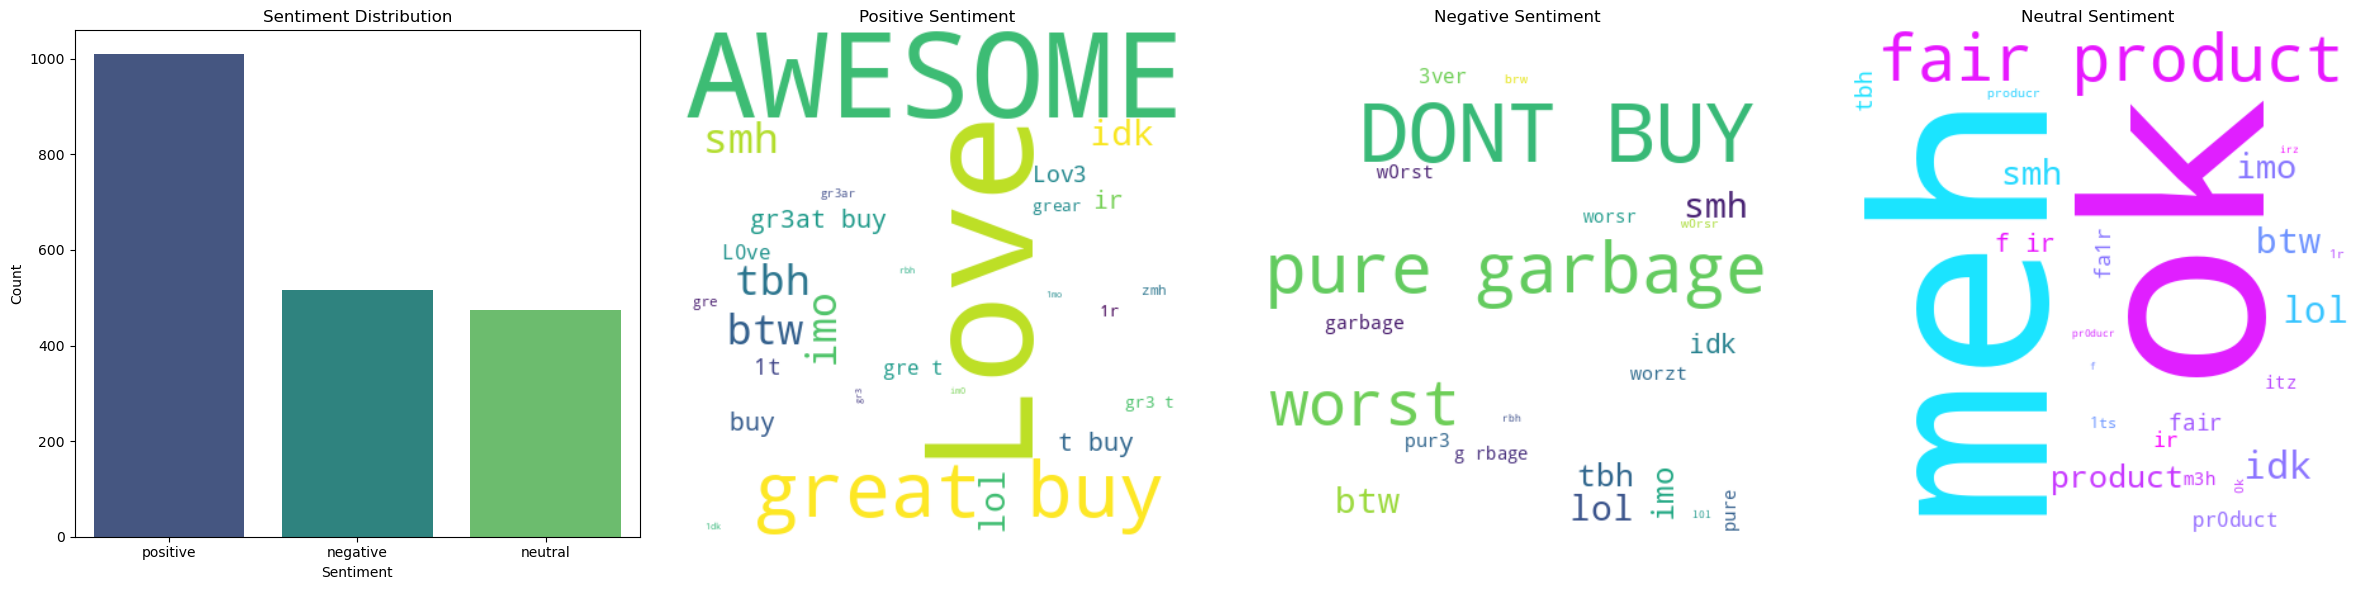

In [4]:
CSV_PATH = "/storage/emulated/0/Documents/CSVs/amazon_advanced_practice.csv"

# 1. Load the raw dataset
df = pd.read_csv(CSV_PATH)

# 2. Clean the target column immediately
df['cleaned_text'] = df['review_headline'].fillna("").apply(clean_text)

# 3. Setup a grid layout: 1 row with 4 columns for your dashboard
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Plot 1: Sentiment Bar Graph
sentiment_counts = df['true_sentiment'].value_counts()
df_plot = pd.DataFrame({
    'Sentiment': sentiment_counts.index.astype(str),
    'Count': sentiment_counts.values
})
sns.barplot(data=df_plot, x='Sentiment', y='Count', hue='Sentiment', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')

# Extract text strings grouped by sentiment label
pos_text = " ".join(df[df['true_sentiment'] == 'positive']['cleaned_text'].astype(str))
neg_text = " ".join(df[df['true_sentiment'] == 'negative']['cleaned_text'].astype(str))
neu_text = " ".join(df[df['true_sentiment'] == 'neutral']['cleaned_text'].astype(str))

# Plot 2: Positive Word Cloud
if pos_text.strip():
    wc_pos = WordCloud(width=400, height=400, background_color='white').generate(pos_text)
    axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Positive Sentiment')
axes[1].axis('off')

# Plot 3: Negative Word Cloud
if neg_text.strip():
    wc_neg = WordCloud(width=400, height=400, background_color='white').generate(neg_text)
    axes[2].imshow(wc_neg, interpolation='bilinear')
axes[2].set_title('Negative Sentiment')
axes[2].axis('off')

# Plot 4: Neutral Word Cloud
if neu_text.strip():
    wc_neu = WordCloud(width=400, height=400, background_color='white', colormap='cool').generate(neu_text)
    axes[3].imshow(wc_neu, interpolation='bilinear')
axes[3].set_title('Neutral Sentiment')
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [5]:
X = df['cleaned_text']
y = df['true_sentiment']

# 1. Stratified balance split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary matrix size: {X_train_tfidf.shape}")

Vocabulary matrix size: (1400, 51)


In [7]:
PREFIX = "amazon_sentiment"

print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Save the Vectorizer and Models to disk storage
joblib.dump(vectorizer, f"{PREFIX}_vectorizer.pkl")
joblib.dump(nb_model, f"{PREFIX}_nb_model.pkl")
joblib.dump(lr_model, f"{PREFIX}_model.pkl")

print(f"\nArtifacts successfully written to disk under prefix: '{PREFIX}'")

Training Multinomial Naive Bayes...
Training Logistic Regression...

Artifacts successfully written to disk under prefix: 'amazon_sentiment'



===== Naive Bayes (In-Memory Test) Classification Report =====
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       155
     neutral       1.00      1.00      1.00       142
    positive       1.00      1.00      1.00       303

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



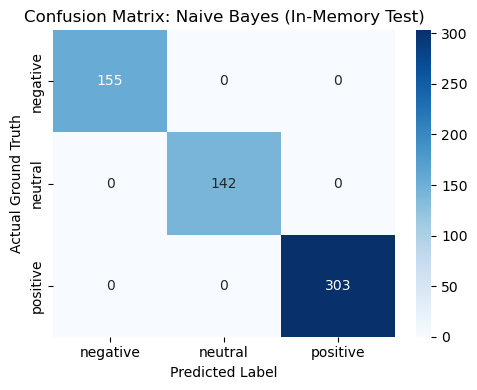


===== Logistic Regression (In-Memory Test) Classification Report =====
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       155
     neutral       1.00      1.00      1.00       142
    positive       1.00      1.00      1.00       303

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



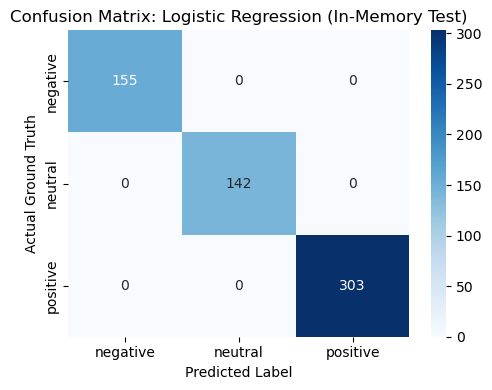

In [8]:
def evaluate_predictions(y_true, y_pred, title='Model Evaluation'):
    """Evaluates generated predictions and prints reports/matrices."""
    print(f"\n===== {title} Classification Report =====")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    unique_labels = sorted(list(set(y_true).union(set(y_pred))))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_labels, yticklabels=unique_labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Ground Truth')
    plt.tight_layout()
    plt.show()

# Generate and evaluate active predictions from memory cache
y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_lr = lr_model.predict(X_test_tfidf)

evaluate_predictions(y_test, y_pred_nb, title='Naive Bayes (In-Memory Test)')
evaluate_predictions(y_test, y_pred_lr, title='Logistic Regression (In-Memory Test)')

In [10]:
def predict_new_text(raw_text_list, model_name='Logistic Regression', prefix='amazon_sentiment'):
    """Bypasses active runtime cache to stream predictions directly from disk files."""
    if isinstance(raw_text_list, str):
        raw_text_list = [raw_text_list]
        
    cleaned_texts = [clean_text(text) for text in raw_text_list]
    model_suffix = 'nb_model.pkl' if model_name == 'Naive Bayes' else 'model.pkl'
    
    # Load parameters
    loaded_vectorizer = joblib.load(f"{prefix}_vectorizer.pkl")
    loaded_model = joblib.load(f"{prefix}_{model_suffix}")
    
    features = loaded_vectorizer.transform(cleaned_texts)
    return loaded_model.predict(features)

 